In [1]:
import gymnasium as gym
import numpy as np
import torch
from tqdm import tqdm

import src.utils as u
from src.agents import DQNCartAgent
from src.plots import draw_bin, draw_rolling_stats


In [2]:
TARGET_PATH = "./data/"

In [3]:
learning_rate = 1e-4
n_episodes = 10_000
start_epsilon = 1.0
epsilon_decay = start_epsilon / n_episodes *10
final_epsilon = 0.01
discount_factor = .95

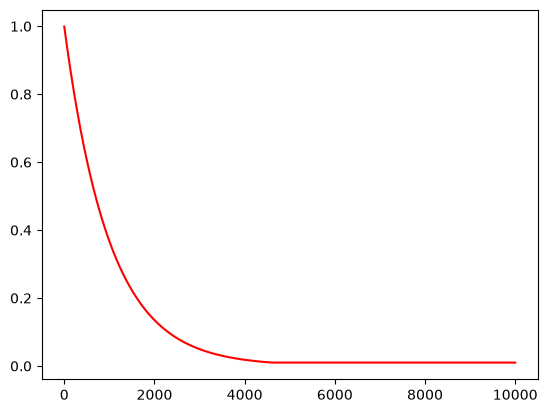

In [4]:
fn = u.exponential_decay(start_epsilon, final_epsilon, 1-epsilon_decay)
draw_bin([fn() for i in range(n_episodes)])

In [5]:
env = gym.make("CartPole-v1", render_mode=None)
env = gym.wrappers.RecordEpisodeStatistics(env, buffer_length=n_episodes)

In [6]:
agent = DQNCartAgent(
    env=env,
    learning_rate=learning_rate,
    initial_epsilon=start_epsilon,
    epsilon_decay=epsilon_decay,
    final_epsilon=final_epsilon,
    decay_fn=u.exponential_decay(start_epsilon, final_epsilon, 1-epsilon_decay),
    discount_factor=discount_factor
)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [09:33<00:00, 17.44it/s]


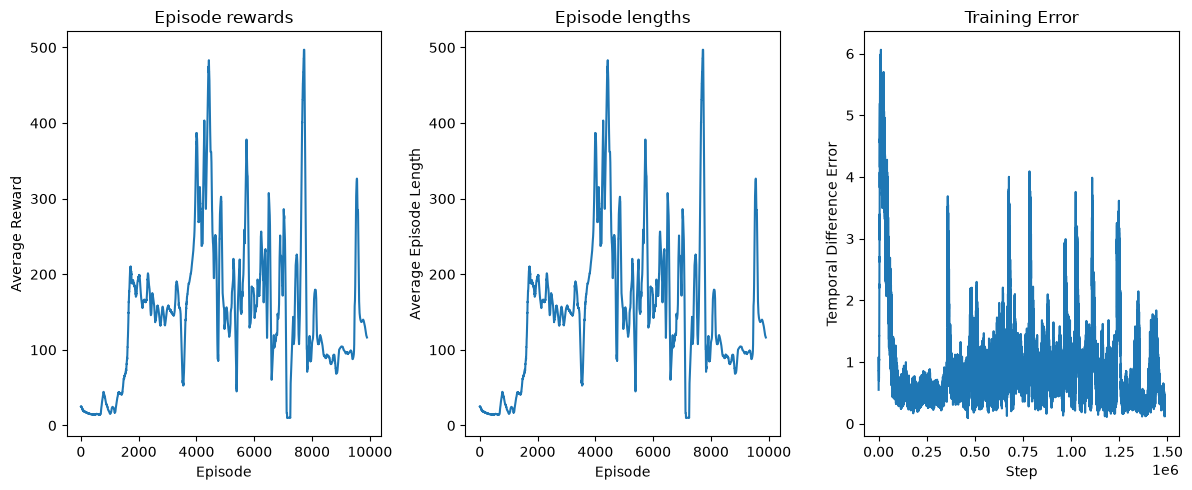

In [7]:
N = n_episodes // 100

for episode in tqdm(range(n_episodes)):
    obs, info = env.reset()
    done = False
    
    while not done:
        action = agent.get_action(obs)
        next_obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        agent.accumulate_train_data(obs, action, reward, next_obs, done)
        agent.update()
        agent.soft_update()
        # step += 1
        # agent.sync_networks(step)

        obs = next_obs

    agent.decay()
    if episode % N == 0:
        torch.save({
            "q_net": agent.q_net.state_dict(),
            "optimizer": agent.optimizer.state_dict(),
            "episode": episode,
        }, f"{TARGET_PATH}checkpoint_{episode}.pt")

torch.save({
    "q_net": agent.q_net.state_dict(),
    "optimizer": agent.optimizer.state_dict(),
    "episode": n_episodes,
}, f"{TARGET_PATH}checkpoint_{n_episodes}.pt")

draw_rolling_stats(env, agent)

## Test

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:12<00:00, 78.25it/s]

avg:  500.0


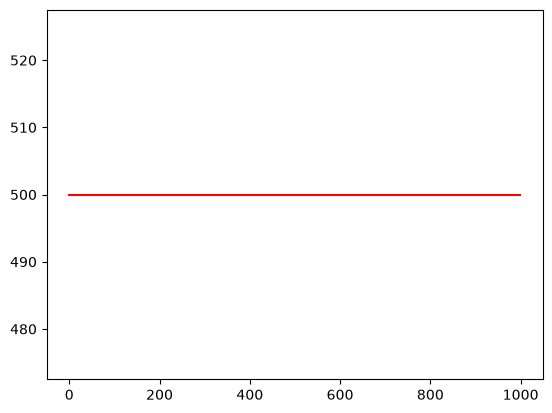

In [17]:
test_env = gym.make("CartPole-v1", render_mode=None)
test_agent = DQNCartAgent(
    env=test_env,
    learning_rate=0,
    initial_epsilon=0,
    epsilon_decay=0,
    final_epsilon=0,
    decay_fn=lambda: 0,
)

# checkpoint = torch.load(f"{TARGET_PATH}checkpoint_{n_episodes}.pt")
checkpoint = torch.load(f"{TARGET_PATH}checkpoint_6000.pt")

test_agent.q_net.load_state_dict(checkpoint["q_net"])
test_agent.target_net.load_state_dict(checkpoint["q_net"])

test_reward = []

for n in tqdm(range(1000)):
    state, _ = test_env.reset()
    done = False
    total_reward = 0

    while not done:
        action = test_agent.get_action(state)
        next_state, reward, terminated, truncated, _ = test_env.step(action)
        done = terminated or truncated
        state = next_state
        total_reward += reward

    test_reward.append(total_reward)


print("avg: ", np.average(test_reward))
draw_bin(test_reward)